In [ ]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

import xarray as xr
xr.set_options(keep_attrs=True)
import numpy as np
np.seterr(divide='ignore', invalid='ignore')

import cartopy
cartopy.config['data_dir'] = "/discover/nobackup/projects/jh_tutorials/JH_examples/JH_datafiles/Cartopy"
cartopy.config['pre_existing_data_dir'] = "/discover/nobackup/projects/jh_tutorials/JH_examples/JH_datafiles/Cartopy"
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import regionmask

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as patches
import matplotlib.colors as mcolors
from matplotlib import cm

# settings
%config InlineBackend.figure_format = 'retina'

# add path to custom functions
module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path + "/py_functions")
from map_plot_tools import *
from colorbar_funcs import *
from data_funcs import *
from stats_funcs import *

dpath0 = '/discover/nobackup/projects/giss/baldwin_nip/dmkumar'
opath  = '../figs'

In [ ]:
def match_lat_lon_names(ds):
    for lat_name in ['y', 'latitude', 'nav_lat']:
        if (lat_name in ds.coords) and ('lat' not in ds.coords):
            ds = ds.rename({lat_name: 'lat'})
    for lon_name in ['x', 'longitude', 'nav_lon']:
        if (lon_name in ds.coords) and ('lon' not in ds.coords):
            ds = ds.rename({lon_name: 'lon'})
    return ds

def jas_seasonal_mean(ds):
    """Weighted JAS seasonal mean (assumes no leap years)."""
    jas = ds.sel(time=ds['time.month'].isin([7, 8, 9]))
    weights = jas['time'].dt.days_in_month
    return (jas * weights).sum(dim='time') / weights.sum(dim='time')

def jas_yearly_mean(ds):
    """Per-year weighted JAS seasonal mean (assumes no leap years)."""
    jas = ds.sel(time=ds['time.month'].isin([7, 8, 9]))
    weights = jas['time'].dt.days_in_month
    return ((jas * weights).groupby('time.year').sum(dim='time') /
            weights.groupby('time.year').sum(dim='time'))

def rotated_box(lon0, lat0, width, height, angle_deg):
    angle = np.deg2rad(angle_deg)
    dx, dy = width / 2, height / 2
    corners = np.array([[-dx, -dy], [dx, -dy], [dx, dy], [-dx, dy]])
    R = np.array([[np.cos(angle), -np.sin(angle)],
                  [np.sin(angle),  np.cos(angle)]])
    rotated = corners @ R.T
    rotated[:, 0] += lon0
    rotated[:, 1] += lat0
    return rotated

def regional_weighted_mean(da, region_name, regions):
    mask3d = regions.mask_3D(da)
    region_index = regions.names.index(region_name)
    masked = da.where(mask3d.sel(region=region_index))
    weights = np.cos(np.deg2rad(da.lat))
    return masked.weighted(weights).mean(("lat", "lon"))

def build_diff_dataset(results, metric, domains, models):
    """Build an xr.Dataset of lr, hr, and hr-lr difference values per domain."""
    ds = xr.Dataset()
    for domain in domains:
        lr_vals = [results['lr'][domain][m][metric] for m in models]
        hr_vals = [results['hr'][domain][m][metric] for m in models]
        lr_da = xr.DataArray(np.array(lr_vals), coords={"model": models}, dims=["model"])
        hr_da = xr.DataArray(np.array(hr_vals), coords={"model": models}, dims=["model"])
        ds[f"{metric}_lr_{domain}"]   = lr_da
        ds[f"{metric}_hr_{domain}"]   = hr_da
        ds[f"{metric}_diff_{domain}"] = hr_da - lr_da
    return ds

In [ ]:
models=['CAM-MPAS',
        'CMCC-CM2',
        #'CNRM-CM6-1',
        'EC-Earth3P',
        'FGOALS-f3',
        'HadGEM3-GC31',
        'HiRAM-SIT',
        'MPI-ESM1-2']#,
        #'MRI-AGCM3-2']

hrkeys=['CAM-MPAS-HR',
        'CMCC-CM2-VHR4',
        #'CNRM-CM6-1-HR',
        'EC-Earth3P-HR',
        'FGOALS-f3-H',
        'HadGEM3-GC31-HM',
        'HiRAM-SIT-HR',
        'MPI-ESM1-2-XR']#,
        #'MRI-AGCM3-2-S']

lrkeys=['CAM-MPAS-LR',
        'CMCC-CM2-HR4',
        #'CNRM-CM6-1',
        'EC-Earth3P',
        'FGOALS-f3-L',
        'HadGEM3-GC31-LM',
        'HiRAM-SIT-LR',
        'MPI-ESM1-2-HR']#,
        #'MRI-AGCM3-2-H']

hr_map = dict(zip(models, hrkeys))
lr_map = dict(zip(models, lrkeys))

key_map = {'hr': hr_map,
           'lr': lr_map}

resolutions = ['lr', 'hr']
experiments = ['highresSST-present', 'highresSST-future']

## If running for the first time, execute these steps
Loads and processes HRMIP highresSST-future data

In [ ]:
### +++ DATA PATHS +++ ###

varn = 'pr'

files = {}
for case in experiments:
    files[case] = {}
    for model in models:
        files[case][model] = {
            'lr': f'{dpath0}/hrmip/{case}/{varn}/{varn}.Amon.{case}.{lr_map[model]}.nc',
            'hr': f'{dpath0}/hrmip/{case}/{varn}/{varn}.Amon.{case}.{hr_map[model]}.nc',
        }

In [ ]:
## +++ LOAD DATA +++ ##

latmin, latmax = 10, 70
lonmin, lonmax = 200, 300

dat_full = {res: {exp: {} for exp in experiments} for res in resolutions}
dat      = {res: {exp: {} for exp in experiments} for res in resolutions}

print('Working on...')
for res in resolutions:
    print(f"\n{res}")
    for case in experiments:
        print(f"  -> {case}")
        for model in models:
            print(f"     ---> {model}")
            ds = xr.open_dataset(files[case][model][res], chunks={'time': 12})[varn]
            ds = ds.sortby('time')
            ds = match_lat_lon_names(ds) * 86400  # mm/s → mm/day
            if case == 'highresSST-future':
                ds = ds.sel(time=slice('2040', '2050'))
            else:
                ds = ds.sel(time=slice('1950', '2014'))
            ds = ds.squeeze()
            ds = ds.drop_vars([c for c in ['member_id', 'dcpp_init_year'] if c in ds.coords])
            dat_full[res][case][model] = ds
            dat[res][case][model]      = ds.sel(lat=slice(latmin, latmax), lon=slice(lonmin, lonmax))

print('\nDone.')

In [43]:
#=== calculate seasonal means

# initialize dictionaries
jas_mean     = { res: { exp: { model: {} for model in models } for exp in experiments } for res in resolutions }
ann_jas_mean = { res: { exp: { model: {} for model in models } for exp in experiments } for res in resolutions }

for res in resolutions:
    for case in experiments:
        for model in models:
            jas_mean[res][case][model] = jas_seasonal_mean(dat[res][case][model])
            ann_jas_mean[res][case][model] = jas_yearly_mean(dat[res][case][model])

print('Done.')

Done.


In [44]:
### +++ COMPARING ALL MODEL 2XCO2 TO MODEL PI +++ ###

# initialize dictionaries
future_diff      = { res: { model: {} for model in models } for res in resolutions } 
future_diff_mask = { res: { model: {} for model in models } for res in resolutions }
future_ptvals    = { res: { model: {} for model in models } for res in resolutions }

print('Significance testing for:')
for res in resolutions:
    print(f'{res}')
    for model in models:
        print(f'-> {model}')
        for varn in varns:
            # calculate significance of future - present difference
            diff_, diff_mask_, ptvals_ = sigtest2n(ann_jas_mean[res]['highresSST-future'][model], ann_jas_mean[res]['highresSST-present'][model],
                                                   jas_mean[res]['highresSST-future'][model], jas_mean[res]['highresSST-present'][model])
            future_diff[res][model] = diff_
            future_diff_mask[res][model] = diff_mask_
            future_ptvals[res][model] = ptvals_

print('Done.')

Significance testing for:
hr
-> CAM-MPAS
-> CMCC-CM2
-> EC-Earth3P
-> FGOALS-f3
-> HadGEM3-GC31
-> HiRAM-SIT
-> MPI-ESM1-2
lr
-> CAM-MPAS
-> CMCC-CM2
-> EC-Earth3P
-> FGOALS-f3
-> HadGEM3-GC31
-> HiRAM-SIT
-> MPI-ESM1-2
Done.


In [ ]:
#=== Store information about model resolution ===
cfg_resolution = {}
for res in resolutions:
    for model in models:
        cfg = lr_map[model] if res == 'lr' else hr_map[model]
        cfg_resolution[cfg] = len(dat_full[res]['highresSST-present'][model].lon)

In [46]:
# Define rectangular polygons (counter-clockwise)

domains = ['core','north']
coords_map = { d: [] for d in domains}
coords_calc = { d: [] for d in domains}

coords_map['core'] = rotated_box(-107, 25, 4.5, 10, angle_deg=35)
coords_calc['core'] = [ ((lon + 360) % 360, lat) for lon, lat in coords_map['core'] ]

coords_map['north'] = rotated_box(-110.5, 32.5, 8, 6, angle_deg=0)
coords_calc['north'] = [ ((lon + 360) % 360, lat) for lon, lat in coords_map['north'] ]

regions = regionmask.Regions(
    outlines=[coords_calc['core'], coords_calc['north']],
    names=["core", "north"],
    abbrevs=["core", "north"]
)

In [14]:
## +++ LOAD OBS DATA +++ ##
#=== Load topo data ===
etopo_full = xr.open_dataset(f'{dpath0}/topo_files/obs.etopo5.zsurf.nc').ROSE.rename({'ETOPO05_X':'lon', 'ETOPO05_Y':'lat'})
etopoNA = etopo_full.where(etopo_full>0, np.nan).sel(lat=slice(latmin,latmax), lon=slice(lonmin,lonmax))

#=== Load precip data ===
trmm = xr.open_dataset(f'{dpath0}/obs_data/prec/pr_TRMM-L3_v7-7A_199801-201312.nc', chunks={'time':12}).pr.sel(lat=slice(latmin,latmax), lon=slice(lonmin,lonmax)) * 86400 # convert from kg m-2 s-1 to mm/day
trmm_jas = jas_seasonal_mean(trmm)

imerg = xr.open_dataset(f'{dpath0}/obs_data/prec/imerg.gn.timeseries.2001-2018.nc' , chunks={'time':12}).precipitation * 24 # convert from mm/hr to mm/day
imerg = imerg.transpose('time','lat','lon')
imerg.attrs['units'] = 'mm/day'
imerg.attrs['Units'] = 'mm/day'
imerg = lonFlip(imerg)
imerg = imerg.sel(lat=slice(latmin,latmax), lon=slice(lonmin,lonmax))
imerg_jas = jas_seasonal_mean(imerg)

# regrid to model resolutions
imerg_regrid = { res: { model: {} for model in models } for res in resolutions } 
for res in resolutions:
    for model, da in dat[res]['highresSST-present'].items():
        imerg_regrid[res][model] = imerg_jas.interp(lat=da.lat, lon=da.lon)


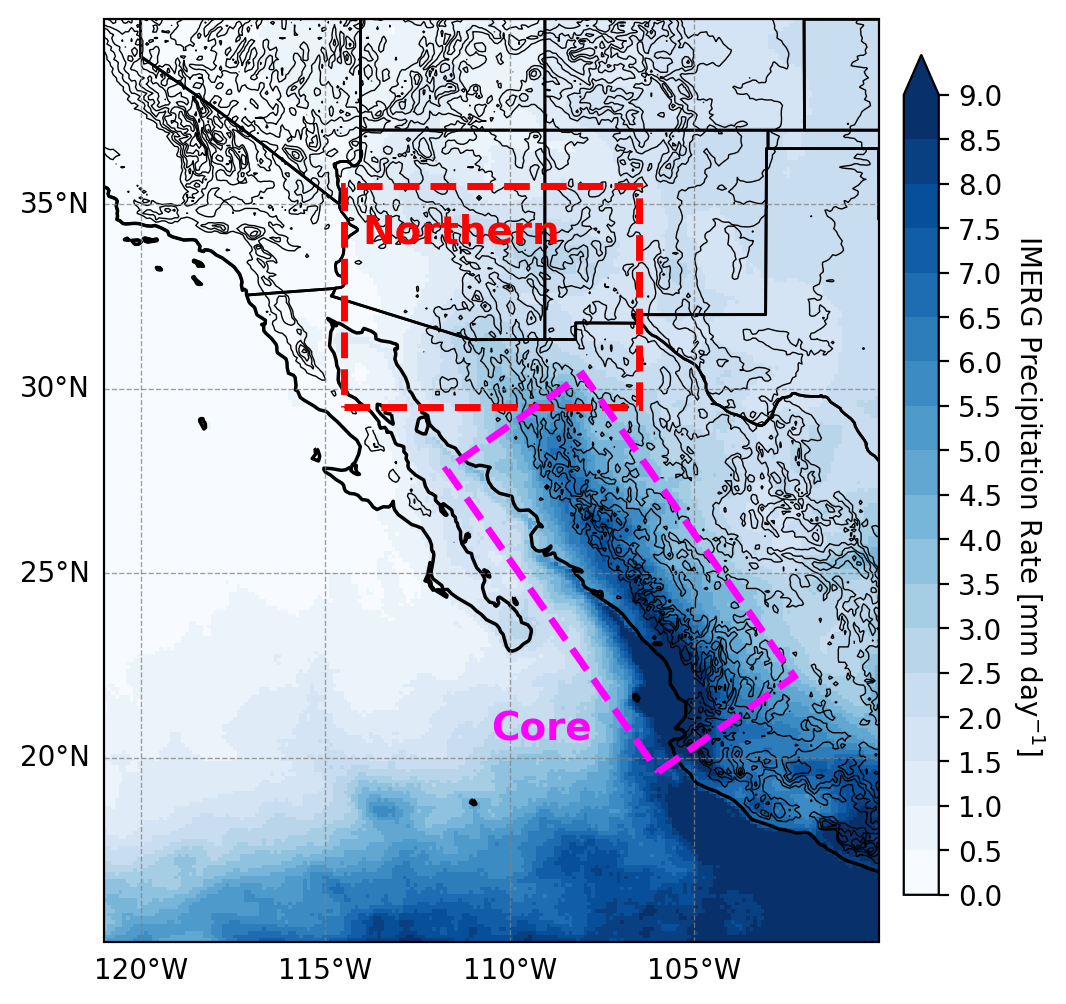

In [15]:
# plot to see how the northern NAM domain bounds lie w.r.t. SMO & North American topography
cmap,_,_,_=get_settings(field='precip', diff=False)
vmin=0
vmax=9
levels=np.linspace(vmin, vmax, 19)
norm=mpl.colors.BoundaryNorm(levels, cmap.N)

fig = plt.figure(figsize=(5, 6))
proj, trans = ccrs.PlateCarree(), ccrs.PlateCarree()
ax = plt.axes(projection=proj)

# obs jas precip
cf = ax.pcolormesh(imerg_jas.lon, imerg_jas.lat, imerg_jas, cmap=cmap, norm=norm, transform=trans)

# etopo05 contours
ax.contour(etopoNA.lon, etopoNA.lat, etopoNA, levels=np.linspace(800,3800,7), linewidths=0.5, colors='k', transform=trans)

# add box around NAM sub-domains
poly1=patches.Polygon(coords_map['north'], closed=True, ec='r', fc='none', lw=2.5, ls='--', transform=ccrs.PlateCarree(), zorder=100); ax.add_patch(poly1)
ax.text(-114, 34.75,'Northern', color='r', fontsize=14, fontweight='bold', ha='left', va='top')

poly2=patches.Polygon(coords_map['core'], closed=True, ec='magenta', fc='none', lw=2.5, ls='--', transform=ccrs.PlateCarree(), zorder=100); ax.add_patch(poly2)
ax.text(-110.5, 20.25,'Core', color='magenta', fontsize=14, fontweight='bold', ha='left', va='bottom')

# map formatting
ax.coastlines(linewidth=1.25)
ax.add_feature(cfeature.BORDERS, edgecolor='k', linewidth=1)
ax.add_feature(cfeature.STATES, edgecolor='k', linewidth=1)
ax.set_extent([239,260,15,40], crs=proj)
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.75, linestyle='--')
gl.top_labels = False; gl.right_labels = False
gl.xlocator = plt.FixedLocator(range(-180, 181, 5))
gl.ylocator = plt.FixedLocator(range(-90, 91, 5))

# colorbar
cax=fig.add_axes([.925, 0.15, 0.035, 0.7])
cbar=fig.colorbar(cf, ticks=levels, orientation='vertical', extend='max', cax=cax)
cbar.set_label('IMERG Precipitation Rate [mm day$^{-1}$]', labelpad=16, rotation=270, size=10, fontweight='normal', ha='center')
cbar.ax.tick_params(labelsize=10)
for tick in cbar.ax.yaxis.get_major_ticks():
    tick.label2.set_fontweight('normal')

In [ ]:
#=== Calculate area-weighted mean pr for core and northern NAM domains ===

results = {res: {d: {} for d in domains} for res in resolutions}

for res in resolutions:
    for domain in domains:
        for model, hist_pr in jas_mean[res]['highresSST-present'].items():
            imerg    = imerg_regrid[res][model]
            fut_diff = future_diff[res][model]

            climo      = regional_weighted_mean(hist_pr, domain, regions).load()
            bias       = regional_weighted_mean(hist_pr - imerg, domain, regions).load()
            pct_change = (fut_diff / hist_pr) * 100
            pct_mean   = regional_weighted_mean(pct_change, domain, regions).load()

            results[res][domain][model] = {
                "climo":      climo,
                "bias":       bias,
                "future_pct": pct_mean,
            }

In [ ]:
## +++ BUILD AND SAVE REGIONAL DIFF DATASETS +++ ##
# Saves one NetCDF per metric; loaded in the Start Here section below.

for metric in ["climo", "bias", "future_pct"]:
    ds = build_diff_dataset(results, metric, domains, models)
    ds.to_netcdf(f"hrmip_nam_prec_{metric}_2040-2050.nc")

# Start Here on Re-Runs

In [ ]:
## +++ CACHE LOGIC +++ ##
# First run:  cells above (data loading → sig testing → regional analysis) must be run first;
#             this cell then writes cache files so subsequent runs are fast.
# Re-runs:    skip to here after running imports / helpers / models / domains / obs cells.

cache_dir   = '../hrmip/cache/'
cache_files = {
    (res, model): os.path.join(
        cache_dir,
        f"pr_future_{'lr' if res == 'lr' else 'hr'}_{lr_map[model] if res == 'lr' else hr_map[model]}.nc"
    )
    for res in resolutions for model in models
}
use_cache = all(os.path.exists(f) for f in cache_files.values())

if use_cache:
    print("Loading from cache...")
    future_diff      = {res: {} for res in resolutions}
    future_diff_mask = {res: {} for res in resolutions}
    jas_mean         = {res: {exp: {} for exp in experiments} for res in resolutions}
    imerg_regrid     = {res: {} for res in resolutions}
    cfg_resolution   = {}

    for res in resolutions:
        for model in models:
            ds  = xr.open_dataset(cache_files[(res, model)])
            cfg = lr_map[model] if res == 'lr' else hr_map[model]
            future_diff[res][model]                    = ds['future_diff']
            future_diff_mask[res][model]               = ds['future_diff_mask']
            jas_mean[res]['highresSST-present'][model] = ds['jas_mean_present']
            jas_mean[res]['highresSST-future'][model]  = ds['jas_mean_future']
            imerg_regrid[res][model]                   = ds['imerg_regrid']
            cfg_resolution[cfg]                        = int(ds.attrs['nlon'])
    print("Done.")

else:
    print("Writing cache for future runs...")
    os.makedirs(cache_dir, exist_ok=True)
    for res in resolutions:
        for model in models:
            cfg    = lr_map[model] if res == 'lr' else hr_map[model]
            ds_out = xr.Dataset({
                'future_diff':      future_diff[res][model],
                'future_diff_mask': future_diff_mask[res][model],
                'jas_mean_present': jas_mean[res]['highresSST-present'][model],
                'jas_mean_future':  jas_mean[res]['highresSST-future'][model],
                'imerg_regrid':     imerg_regrid[res][model],
            })
            ds_out.attrs['nlon'] = cfg_resolution[cfg]
            ds_out.to_netcdf(cache_files[(res, model)])
    print(f"Saved {len(resolutions) * len(models)} cache files to {cache_dir}")

#=== Load pre-saved regional summary datasets (written by cell above) ===
future_pct_2030 = xr.open_dataset('hrmip_nam_prec_future_pct_2030-2050.nc')
future_pct_2040 = xr.open_dataset('hrmip_nam_prec_future_pct_2040-2050.nc')
hist_bias       = xr.open_dataset('hrmip_nam_prec_hist_bias.nc')

## FUTURE CHANGE MAPS - ABSOLUTE VALUES (MM/DAY)

# FIGURES

### Plotting Functions

In [ ]:
def plot_map_grid(get_data, cmap, norm, cbar_label, cbar_ticks,
                  cbar_extend='both', caption=''):
    """Plot a 2 (lr/hr) × n_models grid of maps.

    Parameters
    ----------
    get_data : callable(res, model) → DataArray
    cbar_extend : {'both', 'max', 'min', 'neither'}
    caption : str, optional figure note placed below the axes
    """
    text_kw  = {'color': 'k', 'weight': 'bold', 'size': 14, 'ha': 'center', 'va': 'bottom'}
    text_kw2 = {'color': 'k', 'weight': 'bold', 'size': 20, 'ha': 'center', 'va': 'center'}
    text_kw3 = {'color': 'k', 'weight': 'normal', 'size': 14, 'ha': 'left',   'va': 'center'}
    letters  = list('ABCDEFGHIJKLMNOPQRSTUVWXYZ')
    tx, ty   = -110.5, 40.25
    map_tkw  = {'color': 'black', 'weight': 'normal', 'size': 10}
    trans = proj = ccrs.PlateCarree()
    map_bnds = [239, 260, 15, 40]

    fig, axes = plt.subplots(
        nrows=2, ncols=len(models), figsize=(25, 7),
        layout='constrained', subplot_kw={'projection': proj}
    )

    cf = None
    for i, res in enumerate(['lr', 'hr']):
        for j, model in enumerate(models):
            da = get_data(res, model)
            cf = axes[i, j].pcolormesh(da.lon, da.lat, da, cmap=cmap, norm=norm, transform=trans)
            if i == 0:
                axes[i, j].text(tx, ty, model, **text_kw)

    nrows, ncols = axes.shape
    for k, ax in enumerate(axes.flat):
        row = k // ncols
        col = k % ncols
        poly1 = patches.Polygon(coords_map['north'], closed=True, ec='r', fc='none',
                                lw=2.5, ls='--', transform=ccrs.PlateCarree(), zorder=100)
        poly2 = patches.Polygon(coords_map['core'],  closed=True, ec='magenta', fc='none',
                                lw=2.5, ls='--', transform=ccrs.PlateCarree(), zorder=100)
        ax.add_patch(poly1)
        ax.add_patch(poly2)
        ax.text(-121.5, ty + 1, letters[k], **text_kw2)
        ax.coastlines(color='k', linewidth=.75)
        ax.add_feature(cfeature.STATES,  edgecolor='k', linewidth=.75)
        ax.add_feature(cfeature.BORDERS, edgecolor='k', linewidth=.75)
        ax.set_extent(map_bnds, crs=trans)
        gl = ax.gridlines(crs=trans, lw=.5, colors='black', alpha=1.0,
                          linestyle='--', zorder=10, draw_labels=True)
        gl.bottom_labels = (row == nrows - 1)
        gl.left_labels   = (col == 0)
        gl.top_labels    = False
        gl.right_labels  = False
        gl.xformatter = LONGITUDE_FORMATTER
        gl.yformatter = LATITUDE_FORMATTER
        gl.xlabel_style = map_tkw
        gl.ylabel_style = map_tkw

    if caption:
        fig.text(0.025, -0.05, caption, **text_kw3)

    cax  = fig.add_axes([1.01, 0.1, 0.02, 0.8])
    cbar = fig.colorbar(cf, ticks=cbar_ticks, orientation='vertical',
                        extend=cbar_extend, cax=cax)
    cbar.set_label(cbar_label, labelpad=25, rotation=270, size=14,
                   fontweight='normal', ha='center')
    cbar.ax.tick_params(labelsize=14)
    for tick in cbar.ax.yaxis.get_major_ticks():
        tick.label2.set_fontweight('normal')

    return fig


def plot_scatter_comparison(x_ds, y_ds, xkey_fn, ykey_fn, xlabel, ylabel, suptitle,
                             domains=None, titles=None, xlim=(-50, 50), ylim=(-50, 50),
                             label_offset=(0, -2), label_ha='center',
                             show_oneone=True, show_title=True):
    """Two-panel (per domain) scatter plot.

    Parameters
    ----------
    x_ds, y_ds  : xr.Dataset  — datasets containing x and y values respectively
    xkey_fn, ykey_fn : callable(domain) → variable name in ds
    show_oneone : bool — draw 1:1 diagonal line
    show_title  : bool — draw domain title inside each panel
    """
    if domains is None:
        domains = ['north', 'core']
    if titles is None:
        titles  = ['NORTHERN DOMAIN', 'CORE DOMAIN']

    label_text_kw = dict(fontsize=8, ha=label_ha, va='top', clip_on=True, zorder=100)
    title_text_kw = dict(fontweight='bold', fontsize=12, ha='left', va='top')

    fig, axes = plt.subplots(2, 1, figsize=(5, 8), sharex=True, sharey=True,
                             layout='constrained')

    for ax, domain, title in zip(axes, domains, titles):
        xvals  = x_ds[xkey_fn(domain)].values
        yvals  = y_ds[ykey_fn(domain)].values
        labels = y_ds[ykey_fn(domain)].model.values

        ax.scatter(xvals, yvals, s=50, ec='k', fc='k')
        for x, y, label in zip(xvals, yvals, labels):
            ax.text(x + label_offset[0], y + label_offset[1], label, **label_text_kw)

        if show_title:
            title_x = xlim[0] + 0.02 * (xlim[1] - xlim[0])
            title_y = ylim[1] - 0.02 * (ylim[1] - ylim[0])
            ax.text(title_x, title_y, title, **title_text_kw)

        ax.set(xlim=xlim, ylim=ylim)
        ax.axhline(0, color='k', ls='--', lw=.75)
        ax.axvline(0, color='k', ls='--', lw=.75)
        if show_oneone:
            pad = max(abs(xlim[0]), abs(ylim[0])) + 50
            ax.plot([-pad, pad], [-pad, pad], color='r', ls='-', lw=1, zorder=0)
        ax.set_ylabel(ylabel)

    axes[1].set_xlabel(xlabel)
    if suptitle:
        fig.suptitle(suptitle, fontsize=12)
    return fig

In [ ]:
# Future precip change — significance-masked
dcmap, _, _, _ = get_settings(field='precip', diff=True)
dnorm = mpl.colors.BoundaryNorm(np.linspace(-3, 3, 25), dcmap.N)

plot_map_grid(
    get_data   = lambda res, model: future_diff_mask[res][model],
    cmap       = dcmap,
    norm       = dnorm,
    cbar_label = '$\\Delta$Precipitation [mm/day]',
    cbar_ticks = np.arange(-3, 4, 1),
    caption    = ('Future (2040–2050) − Present (1950–2014) JAS precipitation change. '
                  'Masked for statistical significance. '
                  'Dashed boxes: core (magenta) and northern (red) NAM domains.')
)
#plt.savefig(f'{opath}/highresmip_future_diff_masked.png', bbox_inches='tight')

In [ ]:
# Future precip change — unmasked
dcmap, _, _, _ = get_settings(field='precip', diff=True)
dnorm = mpl.colors.BoundaryNorm(np.linspace(-2, 2, 25), dcmap.N)

plot_map_grid(
    get_data   = lambda res, model: future_diff[res][model],
    cmap       = dcmap,
    norm       = dnorm,
    cbar_label = '$\\Delta$Precipitation [mm/day]',
    cbar_ticks = np.arange(-2, 3, 1),
    caption    = ('Future (2040–2050) − Present (1950–2014) JAS precipitation change. '
                  'Not masked for statistical significance. '
                  'Dashed boxes: core (magenta) and northern (red) NAM domains.')
)
#plt.savefig(f'{opath}/highresmip_future_diff_unmasked.png', bbox_inches='tight')

## FUTURE CHANGE MAPS AS % OF HISTORICAL PR RATE

In [ ]:
# Future precip change as % of historical rate
dcmap, _, _, _ = get_settings(field='precip', diff=True)
dnorm = mpl.colors.BoundaryNorm(np.linspace(-100, 100, 21), dcmap.N)

plot_map_grid(
    get_data   = lambda res, model: (
        future_diff[res][model] / jas_mean[res]['highresSST-present'][model] * 100),
    cmap       = dcmap,
    norm       = dnorm,
    cbar_label = '$\\Delta$Daily Precipitation Rate [%]',
    cbar_ticks = np.linspace(-100, 100, 11),
    caption    = ('Change in relative daily precipitation rate by 2040–2050 due to SSP5-8.5 GHG forcing: '
                  '(future − hist) / hist. Not masked for statistical significance.')
)
#plt.savefig(f'{opath}/highresmip_future_pct_change.png', bbox_inches='tight')

## HISTORICAL AND FUTURE PR CLIMO MAPS

In [ ]:
# Historical JAS climatology
pcmap, _, _, _ = get_settings(field='precip', diff=False)
pnorm = mpl.colors.BoundaryNorm(np.linspace(0, 12, 25), pcmap.N)

plot_map_grid(
    get_data     = lambda res, model: jas_mean[res]['highresSST-present'][model],
    cmap         = pcmap,
    norm         = pnorm,
    cbar_label   = 'Precipitation Rate [mm/day]',
    cbar_ticks   = np.arange(0, 13, 1),
    cbar_extend  = 'max',
    caption      = ('Mean JAS daily precipitation rate — historical period (1950–2014). '
                    'Dashed boxes: core (magenta) and northern (red) NAM domains.')
)
#plt.savefig(f'{opath}/highresmip_hist_climo.png', bbox_inches='tight')

In [ ]:
# Future JAS climatology
pcmap, _, _, _ = get_settings(field='precip', diff=False)
pnorm = mpl.colors.BoundaryNorm(np.linspace(0, 12, 25), pcmap.N)

plot_map_grid(
    get_data     = lambda res, model: jas_mean[res]['highresSST-future'][model],
    cmap         = pcmap,
    norm         = pnorm,
    cbar_label   = 'Precipitation Rate [mm/day]',
    cbar_ticks   = np.arange(0, 13, 1),
    cbar_extend  = 'max',
    caption      = ('Mean JAS daily precipitation rate — future period (2040–2050), SSP5-8.5 GHG forcing. '
                    'Dashed boxes: core (magenta) and northern (red) NAM domains.')
)
#plt.savefig(f'{opath}/highresmip_future_climo.png', bbox_inches='tight')

## RELATIONSHIP BETWEEN MAGNITUDE OF FUTURE DRYING VS. HISTORICAL PR RATE

In [ ]:
# Historical bias vs. IMERG
dcmap, _, _, _ = get_settings(field='precip', diff=True)
dnorm = mpl.colors.BoundaryNorm(np.linspace(-3, 3, 13), dcmap.N)

plot_map_grid(
    get_data     = lambda res, model: jas_mean[res]['highresSST-present'][model] - imerg_regrid[res][model],
    cmap         = dcmap,
    norm         = dnorm,
    cbar_label   = 'Precipitation Bias [mm/day]',
    cbar_ticks   = np.linspace(-3, 3, 13),
    cbar_extend  = 'both',
    caption      = 'Historical JAS precipitation bias vs. IMERG. Dashed boxes: core (magenta) and northern (red) NAM domains.'
)
#plt.savefig(f'{opath}/highresmip_hist_bias.png', bbox_inches='tight')

#### Plot regional mean biases

In [31]:
def plot_panel_horizontal(ax, dat_lr, dat_hr):

    line_kw = dict(color='0.7', lw=2, zorder=1)
    marker_kw = dict(marker='s', edgecolor='k', linewidth=0.8, zorder=3)

    yvals = np.arange(len(models))
    
    for y, model in zip(yvals, models):

        lr_cfg = lr_map[model]
        hr_cfg = hr_map[model]

        lr_val = dat_lr.sel(model=model)
        hr_val = dat_hr.sel(model=model)

        lr_size = 40000 / cfg_resolution[lr_cfg]
        hr_size = 40000 / cfg_resolution[hr_cfg]

        ax.scatter(lr_val, y, s=lr_size, facecolor='black', **marker_kw)
        ax.scatter(hr_val, y, s=hr_size, facecolor='darkgoldenrod', **marker_kw)

        ax.plot([lr_val, hr_val], [y, y], **line_kw)

    ax.axvline(0, color='k', ls='--', lw=1)

    ax.set_yticks(yvals)
    ax.set_yticklabels(models)
    
    ax.invert_yaxis()

    ax.xaxis.tick_top()
    ax.tick_params(axis='x', bottom=False, labelbottom=False)

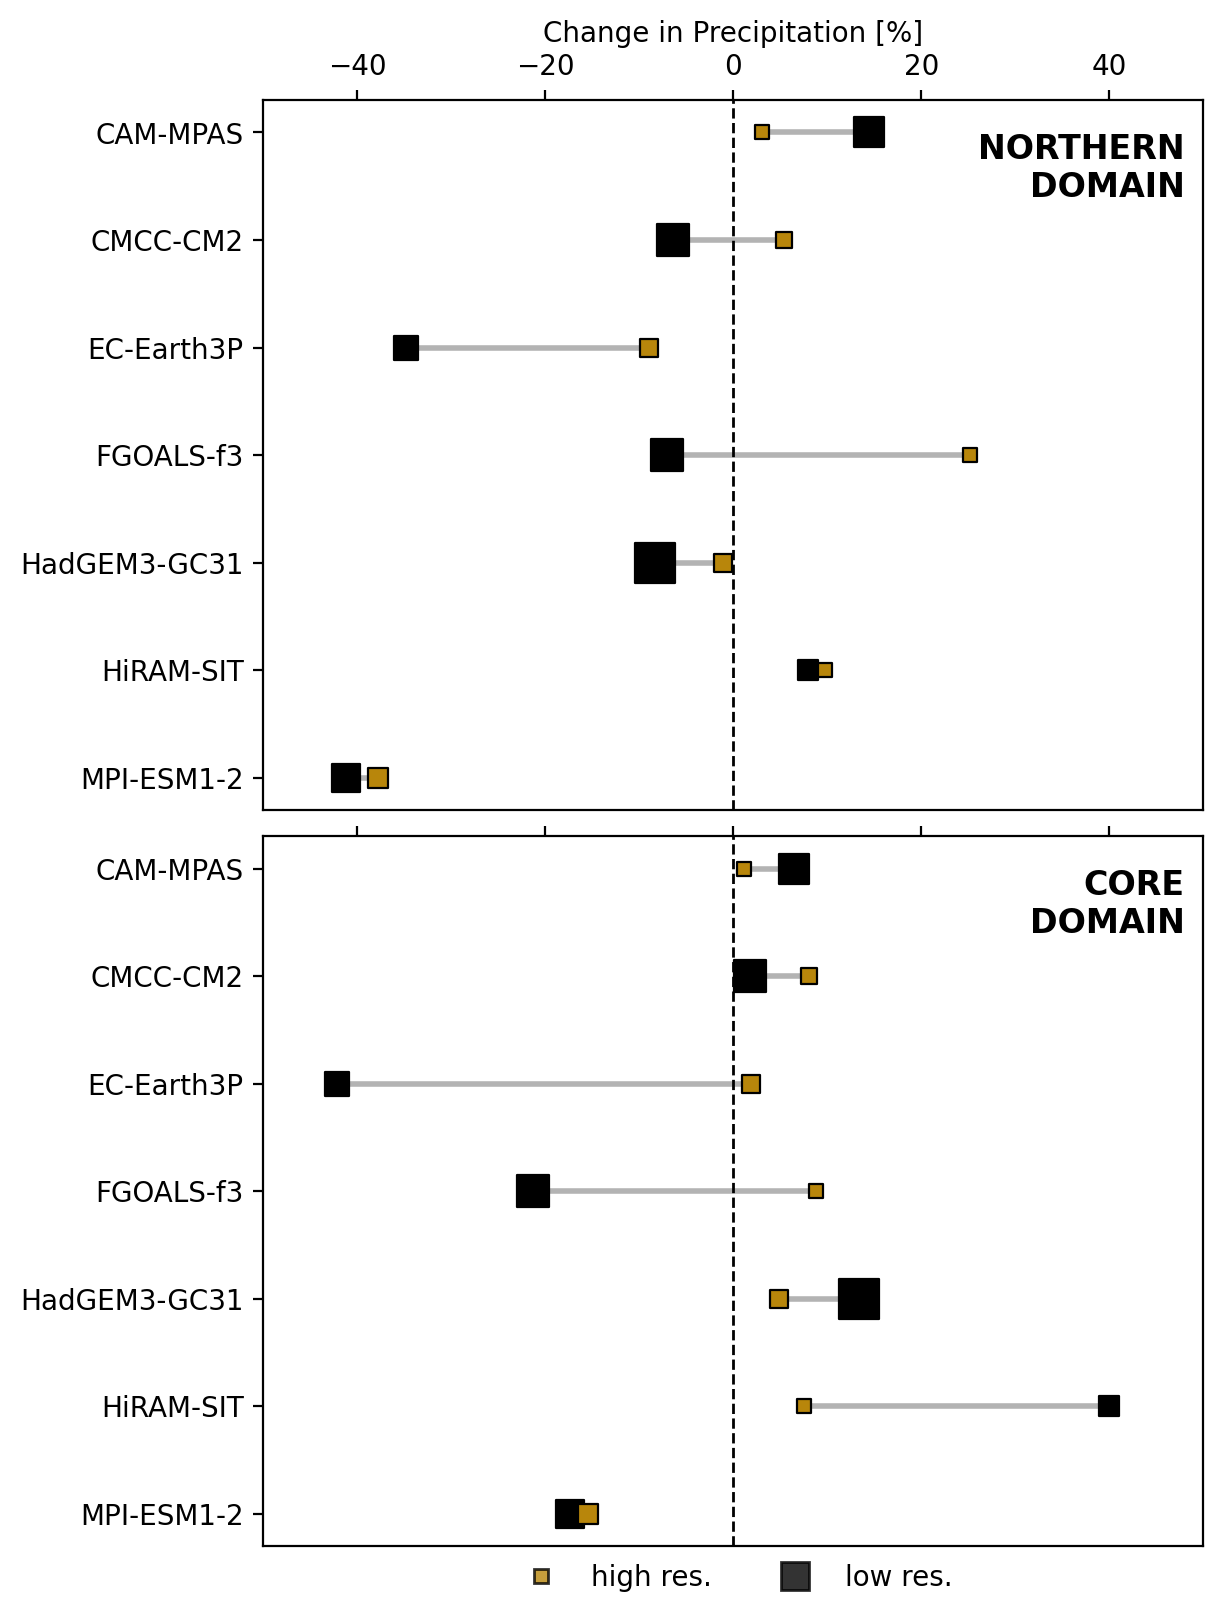

In [42]:
text_kw={'size':12, 'weight':'bold','color':'black', 'ha':'right', 'va':'top'}
legend_kw={'loc':'lower center', 'bbox_to_anchor':(.5,-0.1), 'ncol':2, 'fontsize':10, 'labelcolor':'k', 'frameon':False}
legend_handles = [ Line2D([0], [0], marker='s', color='w', alpha=.8,
                       markeredgecolor='k', markerfacecolor='darkgoldenrod',
                       markersize=5, label='high res.'),
                    Line2D([0], [0], marker='s', color='w', alpha=.8,
                       markeredgecolor='k', markerfacecolor='k',
                       markersize=10, label='low res.') ]
titles=['NORTHERN\nDOMAIN', 'CORE\nDOMAIN']
fig, axes = plt.subplots(2, 1, figsize=(6,8), sharex=False, constrained_layout=True)

for ax, domain, title in zip(axes, domains, titles):
    
    #dat_lr = bias_2040[f'bias_lr_{domain}']
    #dat_hr = bias_2040[f'bias_hr_{domain}']

    dat_lr = future_pct_2030[f'future_pct_lr_{domain}']
    dat_hr = future_pct_2030[f'future_pct_hr_{domain}']
    
    ax.text(48, 0, title, **text_kw)
    plot_panel_horizontal(ax, dat_lr, dat_hr)

    if domain=='north':
        ax.set_xlabel('Change in Precipitation [%]')
        ax.set(xlim=[-50,50])
        ax.xaxis.set_label_position('top')
    else:
        ax.set(xlim=[-50,50])
        ax.tick_params(axis='x', bottom=False, labeltop=False)
        ax.legend(handles=legend_handles, **legend_kw)

In [ ]:
# 2040–2050: Low-Res. vs High-Res. future % change
plot_scatter_comparison(
    x_ds         = future_pct_2040,
    y_ds         = future_pct_2040,
    xkey_fn      = lambda d: f'future_pct_lr_{d}',
    ykey_fn      = lambda d: f'future_pct_hr_{d}',
    xlabel       = 'Low-Res.',
    ylabel       = 'High-Res.',
    suptitle     = '% Prec Change (Future$-$Hist / Hist)',
)

Text(0, 0.5, '2030-2050 Mean')

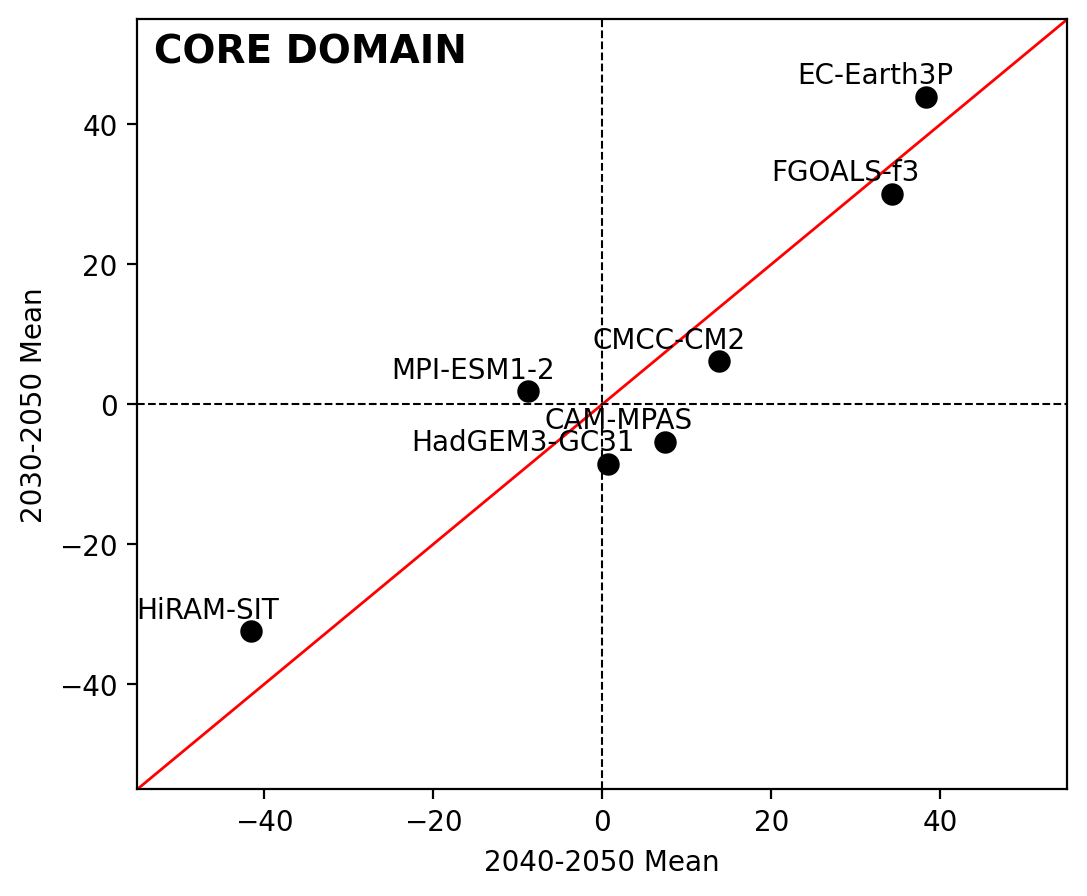

In [82]:
fig = plt.figure(figsize=(6,5))
ax = plt.axes()

xvals = future_pct_2040['future_pct_diff_core'].values
yvals = future_pct_2030['future_pct_diff_core'].values
labels = future_pct_2030['future_pct_diff_core'].model.values

ax.scatter(xvals, yvals, s=50, ec='k', fc='k')
for x, y, label in zip(xvals, yvals, labels):
    ax.text(x+3.2, y+1, label, fontsize=10, ha='right', va='bottom', clip_on=True, zorder=100)
    
ax.text(-53,53, 'CORE DOMAIN', fontweight='bold', fontsize=14, ha='left', va='top')
ax.set(xlim=[-55,55],ylim=[-55,55])
ax.axhline(0, color='k', ls='--', lw=.75)
ax.axvline(0, color='k', ls='--', lw=.75)
ax.plot([-200, 200], [-200, 200],
        color='r', linestyle='-', linewidth=1, zorder=0)

ax.set_xlabel('2040-2050 Mean')
ax.set_ylabel('2030-2050 Mean')
#ax.legend()

Text(0.5, 1.0, '% Prec Change (Future$-$Hist / Hist)')

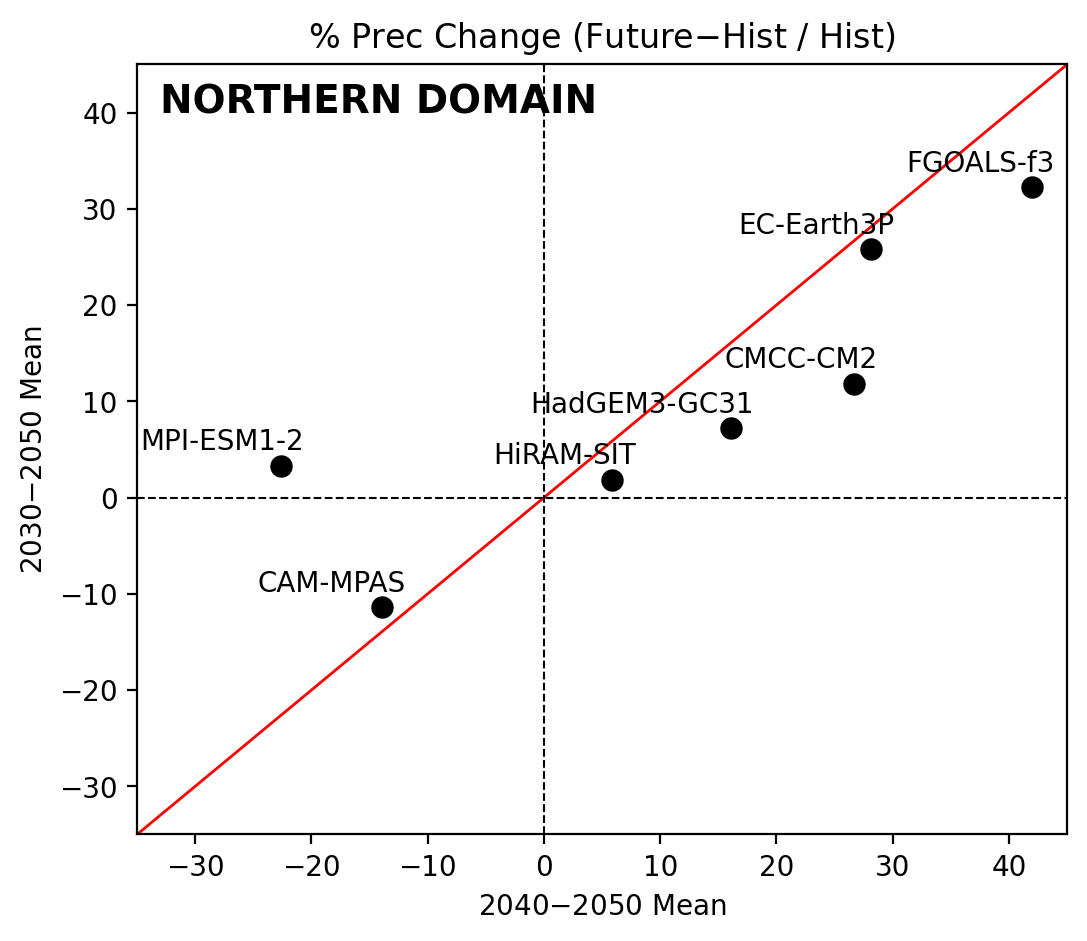

In [81]:
fig = plt.figure(figsize=(6,5))
ax = plt.axes()

xvals = future_pct_2040['future_pct_diff_north'].values
yvals = future_pct_2030['future_pct_diff_north'].values
labels = future_pct_2030['future_pct_diff_north'].model.values

ax.scatter(xvals, yvals, s=50, ec='k', fc='k')
for x, y, label in zip(xvals, yvals, labels):
    ax.text(x+2, y+1, label, fontsize=10, ha='right', va='bottom', clip_on=True, zorder=100)
    
ax.text(-33,43, 'NORTHERN DOMAIN', fontweight='bold', fontsize=14, ha='left', va='top')
ax.set(xlim=[-35,45],ylim=[-35,45])
ax.axhline(0, color='k', ls='--', lw=.75)
ax.axvline(0, color='k', ls='--', lw=.75)
ax.plot([-200, 200], [-200, 200],
        color='r', linestyle='-', linewidth=1, zorder=0)

ax.set_xlabel('2040$-$2050 Mean')
ax.set_ylabel('2030$-$2050 Mean')
ax.set_title('% Prec Change (Future$-$Hist / Hist)', size=12)

In [ ]:
# High-Res.: 2040–2050 vs 2030–2050 future % change
plot_scatter_comparison(
    x_ds         = future_pct_2040,
    y_ds         = future_pct_2030,
    xkey_fn      = lambda d: f'future_pct_hr_{d}',
    ykey_fn      = lambda d: f'future_pct_hr_{d}',
    xlabel       = 'High-Res. 2040$-$2050 Mean',
    ylabel       = 'High-Res. 2030$-$2050 Mean',
    suptitle     = '% Prec Change (Future$-$Hist / Hist)',
)

In [ ]:
# Low-Res.: 2040–2050 vs 2030–2050 future % change
plot_scatter_comparison(
    x_ds         = future_pct_2040,
    y_ds         = future_pct_2030,
    xkey_fn      = lambda d: f'future_pct_lr_{d}',
    ykey_fn      = lambda d: f'future_pct_lr_{d}',
    xlabel       = 'Low-Res. 2040$-$2050 Mean',
    ylabel       = 'Low-Res. 2030$-$2050 Mean',
    suptitle     = '% Prec Change (Future$-$Hist / Hist)',
)

In [ ]:
# HR–LR difference: 2040–2050 vs 2030–2050
plot_scatter_comparison(
    x_ds     = future_pct_2040,
    y_ds     = future_pct_2030,
    xkey_fn  = lambda d: f'future_pct_diff_{d}',
    ykey_fn  = lambda d: f'future_pct_diff_{d}',
    xlabel   = '2040$-$2050 High-Res.$-$Low-Res. Difference',
    ylabel   = '2030$-$2050 High-Res.$-$Low-Res. Difference',
    suptitle = ('Impact of averaging across 2030-2050 vs 2040-2050\n'
                'On High-Res.$-$Low-Res. Difference in their\n'
                '% Prec Change (Future$-$Hist / Hist)'),
    xlim         = (-50, 50),
    ylim         = (-50, 50),
    label_offset = (0, -2),
    label_ha     = 'center',
)

Text(0, 0.5, 'High-Res.')

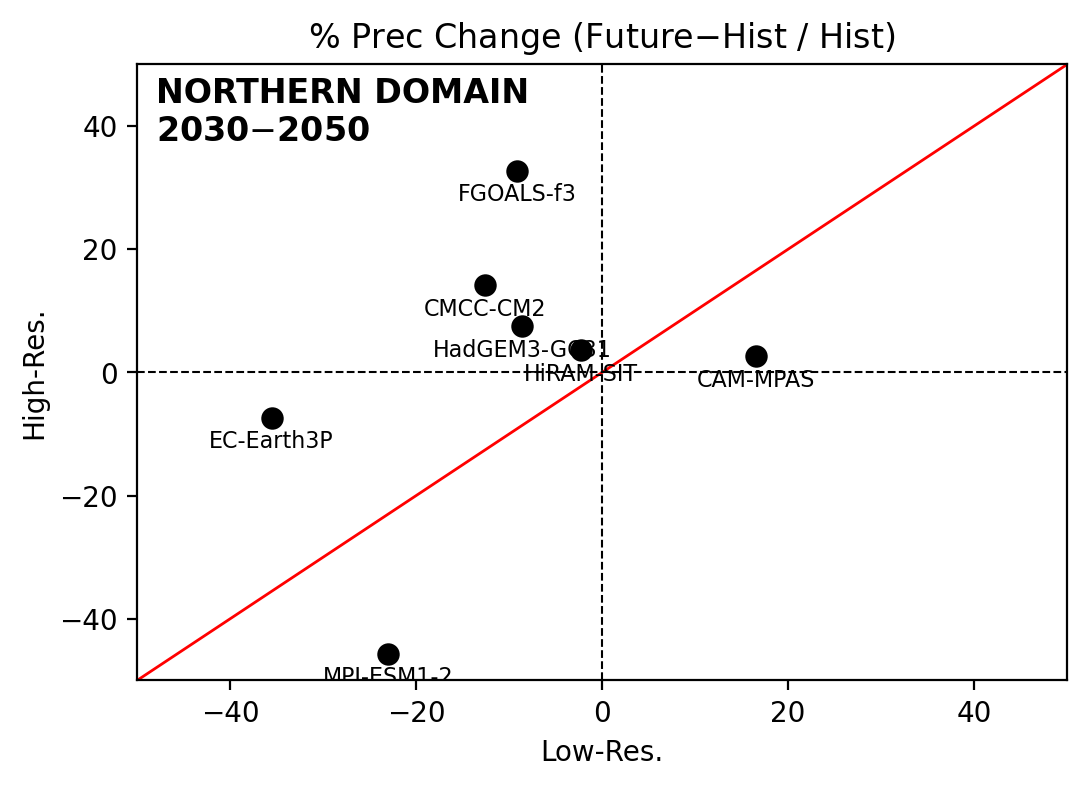

In [113]:
fig = plt.figure(figsize=(6,5))
ax = plt.axes()

xvals = future_pct_2030['future_pct_lr_north'].values
yvals = future_pct_2030['future_pct_hr_north'].values
labels = future_pct_2030['future_pct_hr_north'].model.values

ax.scatter(xvals, yvals, s=50, ec='k', fc='k')
for x, y, label in zip(xvals, yvals, labels):
    ax.text(x, y-2, label, fontsize=8, ha='center', va='top', clip_on=True, zorder=100)

ax.set_title('% Prec Change (Future$-$Hist / Hist)')
ax.text(-48,48, 'NORTHERN DOMAIN\n2030$-$2050', fontweight='bold', fontsize=12, ha='left', va='top')
ax.set(xlim=[-50,50],ylim=[-50,50])
ax.axhline(0, color='k', ls='--', lw=.75)
ax.axvline(0, color='k', ls='--', lw=.75)
ax.plot([-200, 200], [-200, 200],
        color='r', linestyle='-', linewidth=1, zorder=0)

ax.set_xlabel('Low-Res.')
ax.set_ylabel('High-Res.')

Text(0, 0.5, 'High-Res.')

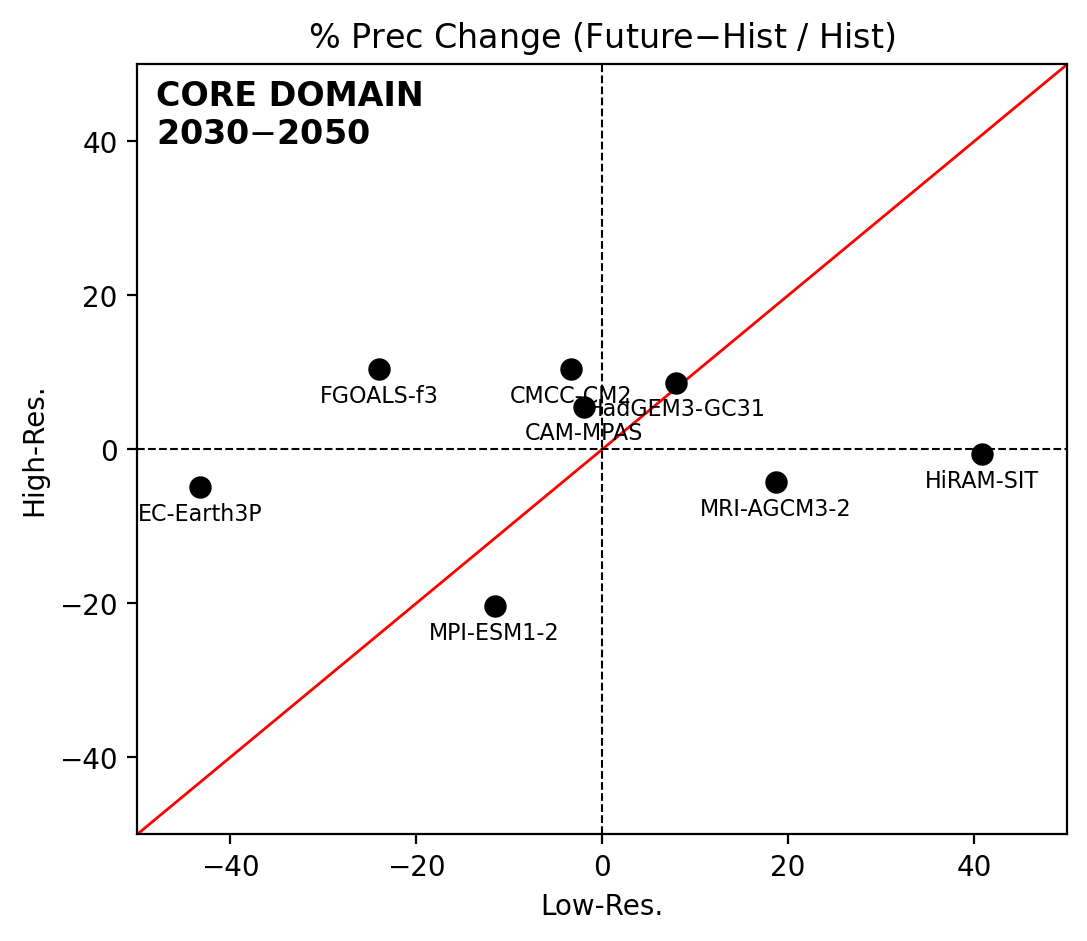

In [27]:
fig = plt.figure(figsize=(6,5))
ax = plt.axes()

xvals = future_pct_2030['future_pct_lr_core'].values
yvals = future_pct_2030['future_pct_hr_core'].values
labels = future_pct_2030['future_pct_hr_core'].model.values

ax.scatter(xvals, yvals, s=50, ec='k', fc='k')
for x, y, label in zip(xvals, yvals, labels):
    ax.text(x, y-2, label, fontsize=8, ha='center', va='top', clip_on=True, zorder=100)

ax.set_title('% Prec Change (Future$-$Hist / Hist)')
ax.text(-48,48, 'CORE DOMAIN\n2030$-$2050', fontweight='bold', fontsize=12, ha='left', va='top')
ax.set(xlim=[-50,50],ylim=[-50,50])
ax.axhline(0, color='k', ls='--', lw=.75)
ax.axvline(0, color='k', ls='--', lw=.75)
ax.plot([-200, 200], [-200, 200],
        color='r', linestyle='-', linewidth=1, zorder=0)

ax.set_xlabel('Low-Res.')
ax.set_ylabel('High-Res.')

In [ ]:
# Historical bias: Low-Res. vs High-Res.
plot_scatter_comparison(
    x_ds     = hist_bias,
    y_ds     = hist_bias,
    xkey_fn  = lambda d: f'bias_lr_{d}',
    ykey_fn  = lambda d: f'bias_hr_{d}',
    xlabel   = 'Low-Res.',
    ylabel   = 'High-Res.',
    suptitle = 'Historical Prec Bias (mm/day)',
    xlim         = (-2, 0.5),
    ylim         = (-2, 0.5),
    label_offset = (-0.02, -0.02),
    label_ha     = 'right',
)

In [ ]:
# Historical bias diff vs future % change diff
plot_scatter_comparison(
    x_ds     = hist_bias,
    y_ds     = future_pct_2030,
    xkey_fn  = lambda d: f'bias_diff_{d}',
    ykey_fn  = lambda d: f'future_pct_diff_{d}',
    xlabel   = 'High-Res.$-$Low-Res.\nDifference in Historical Precipitation Bias (mm/day)',
    ylabel   = 'High-Res.$-$Low-Res.\nDifference in Future Prec Change (%)',
    suptitle = None,
    xlim         = (-2, 2),
    ylim         = (-45, 45),
    label_offset = (-0.05, -0.2),
    label_ha     = 'right',
    show_oneone  = False,
    show_title   = False,
)